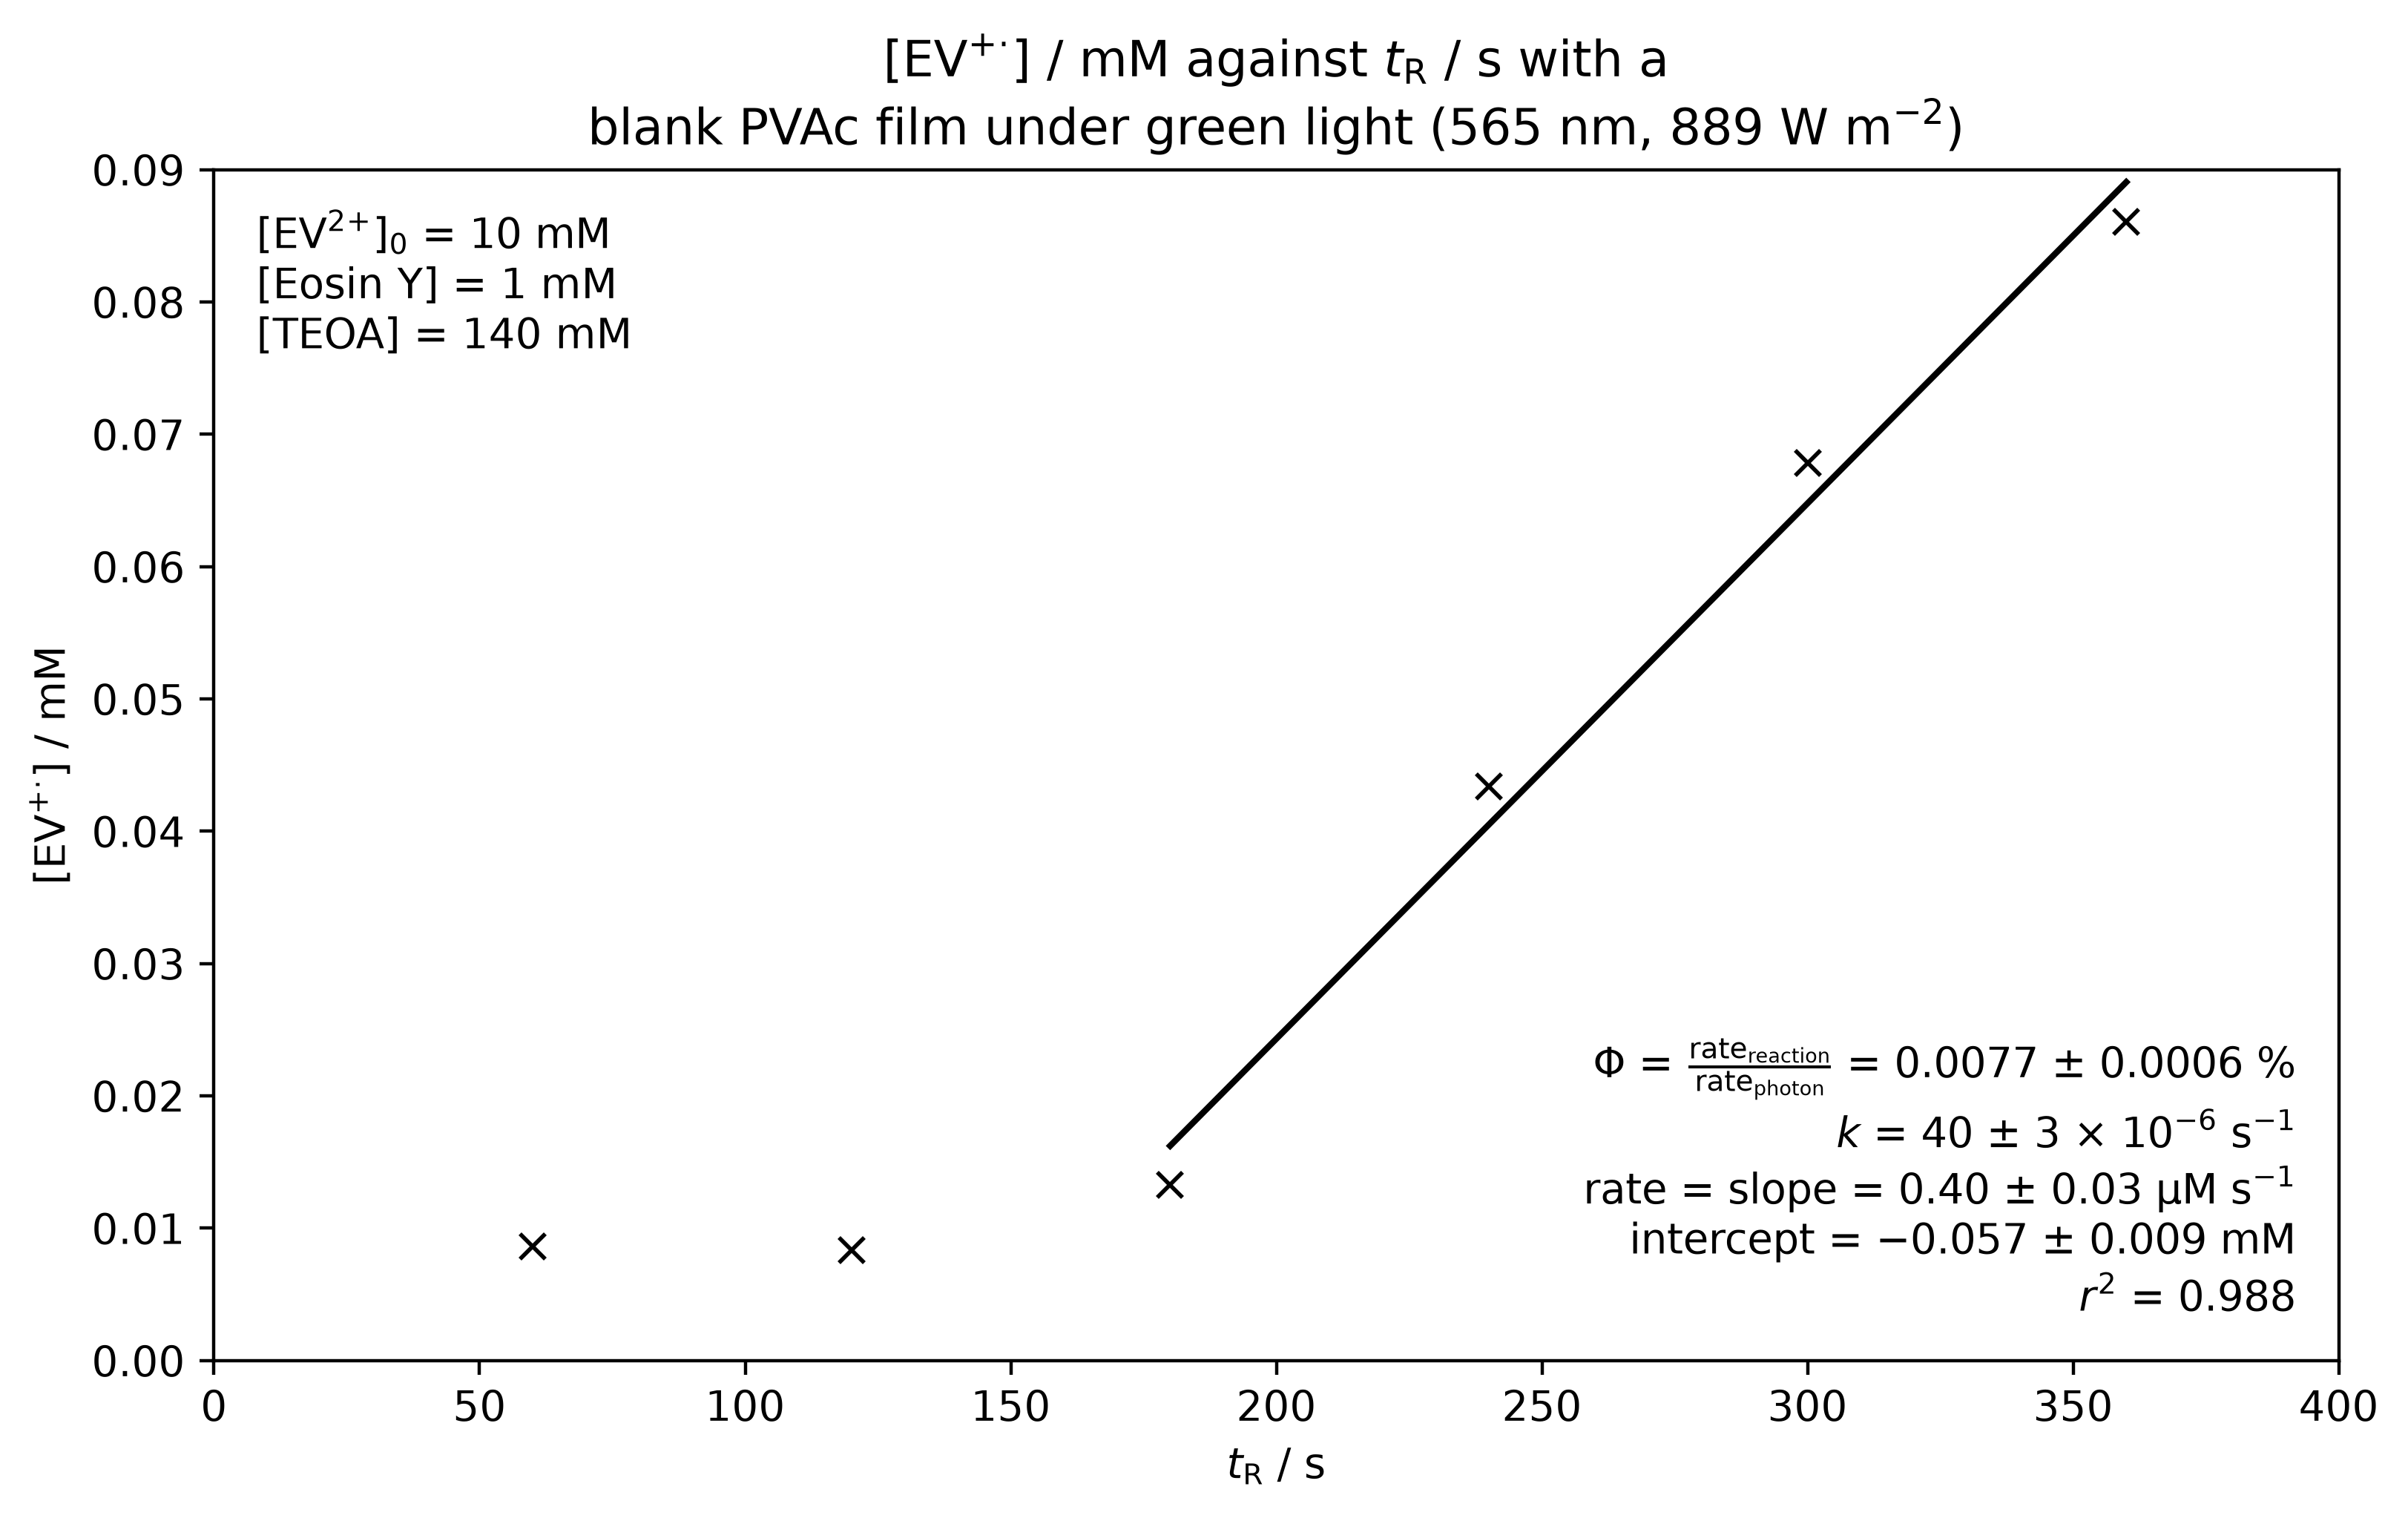

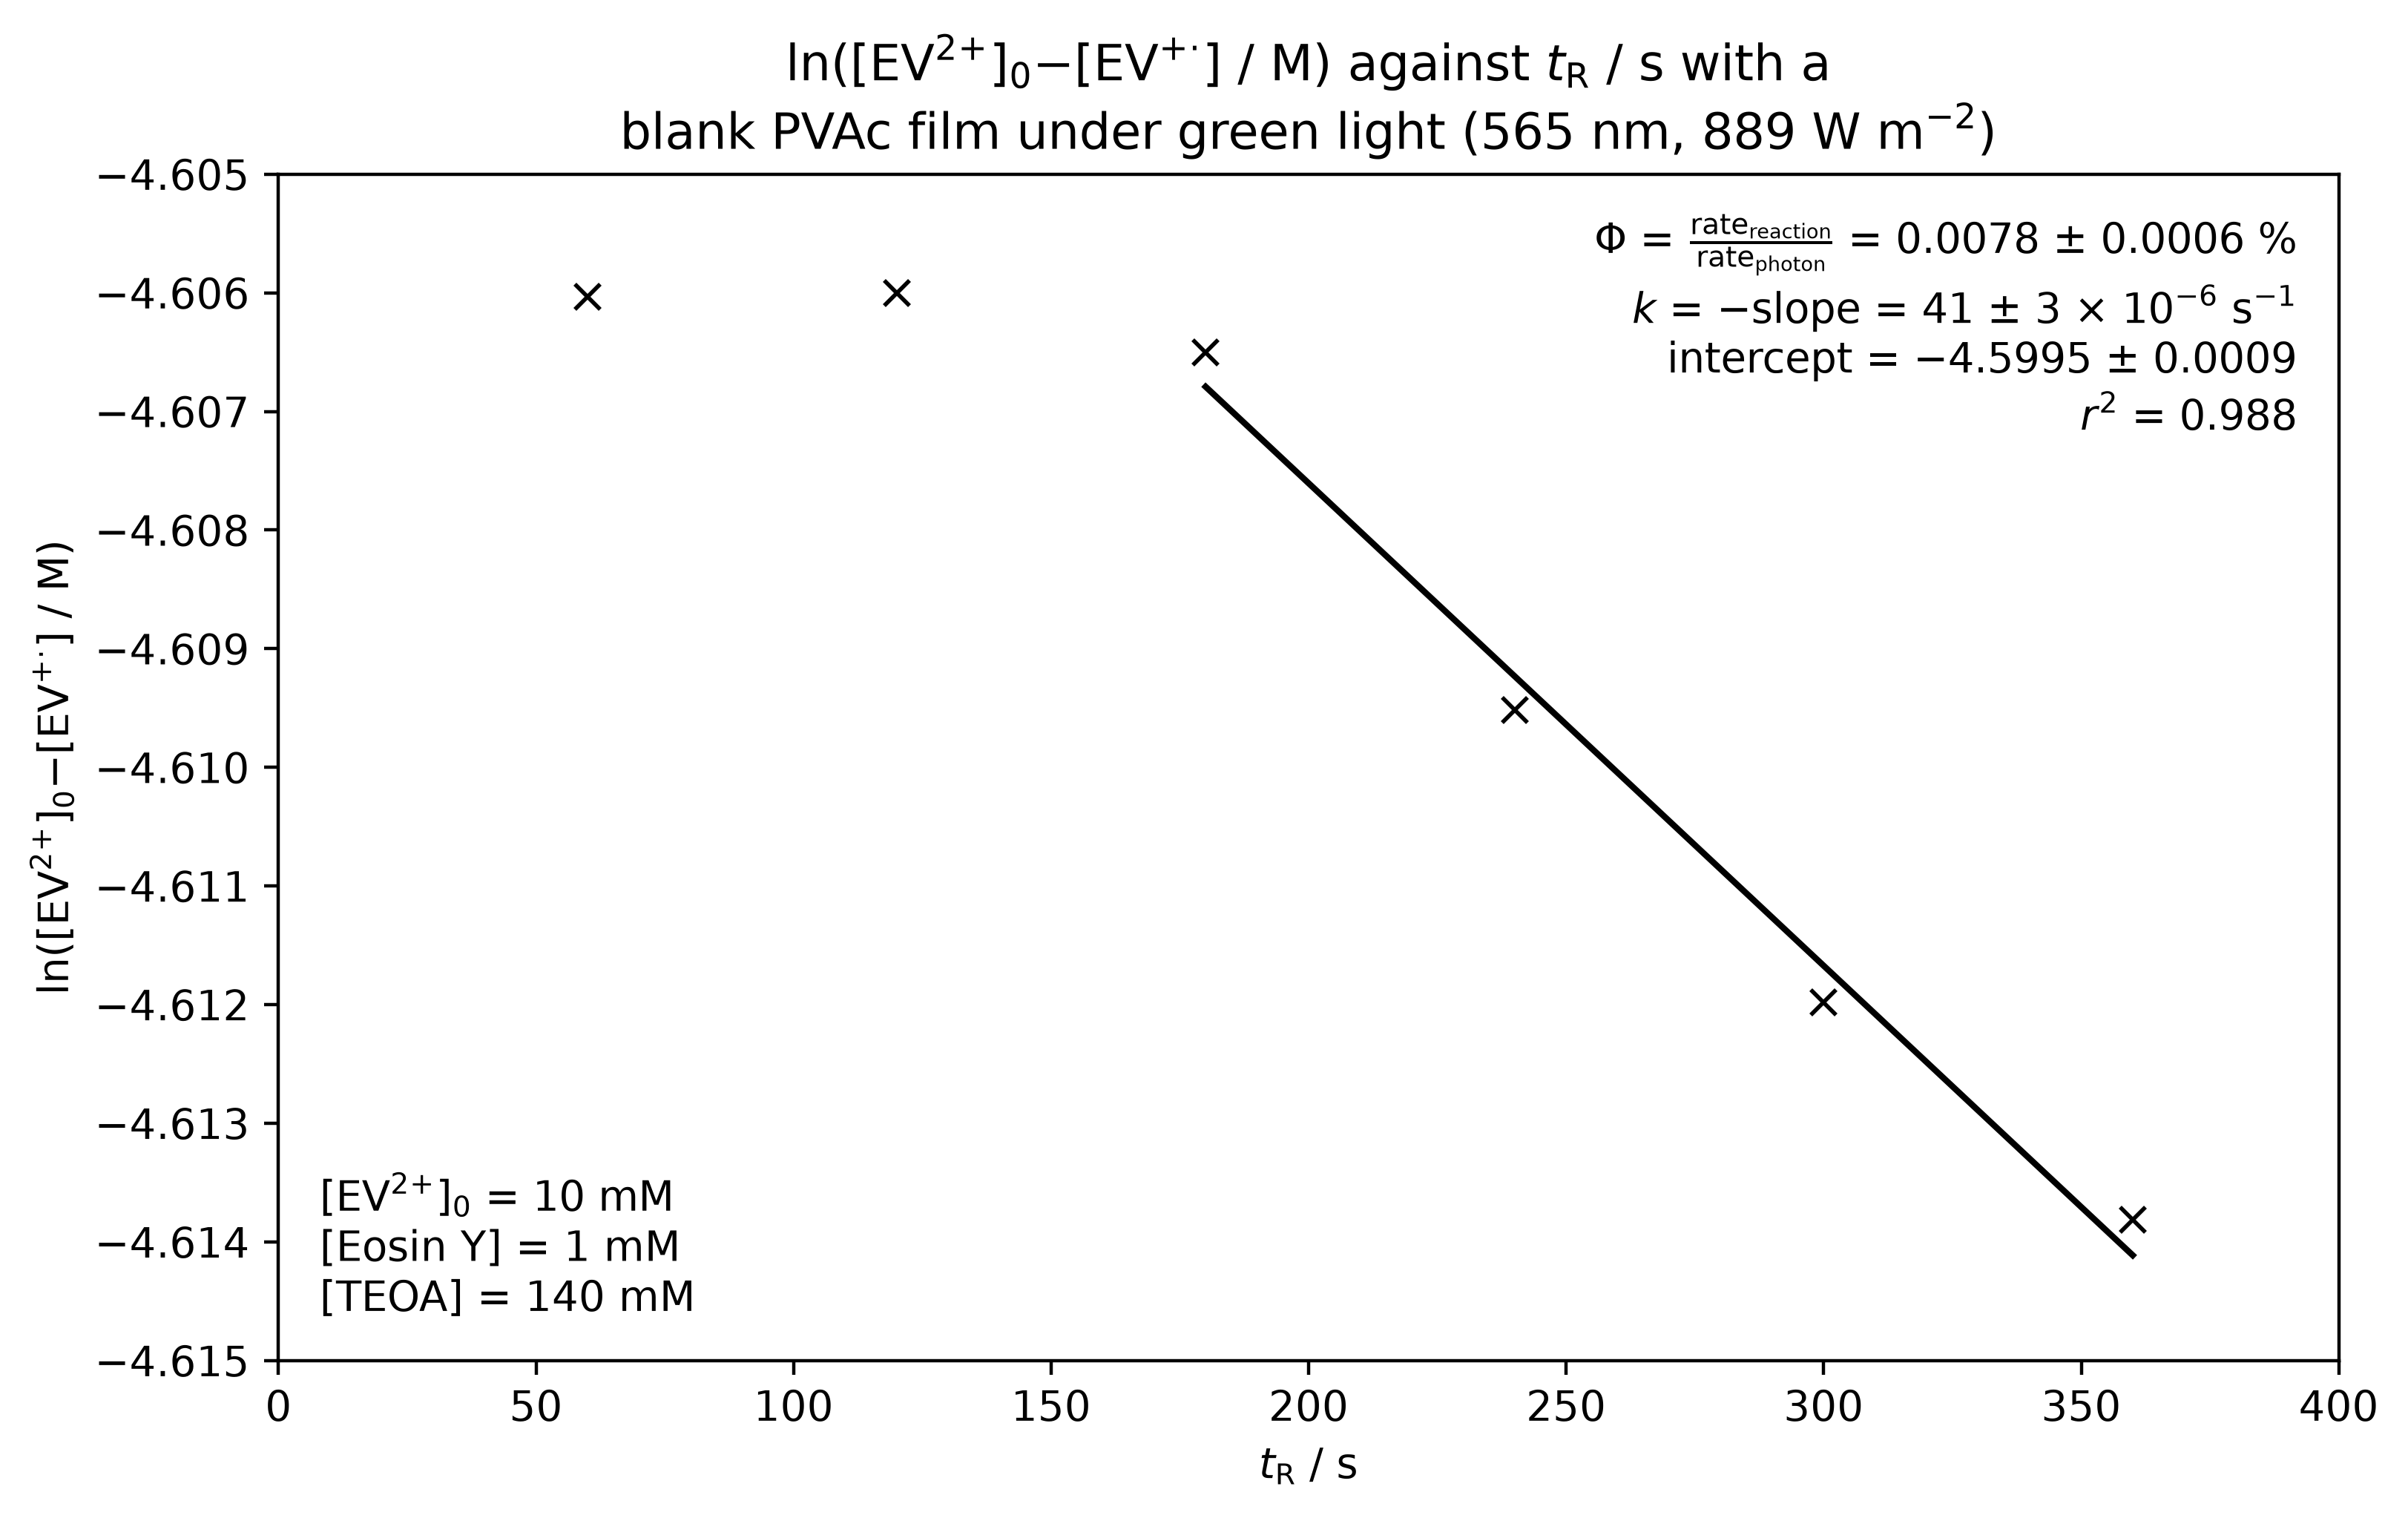

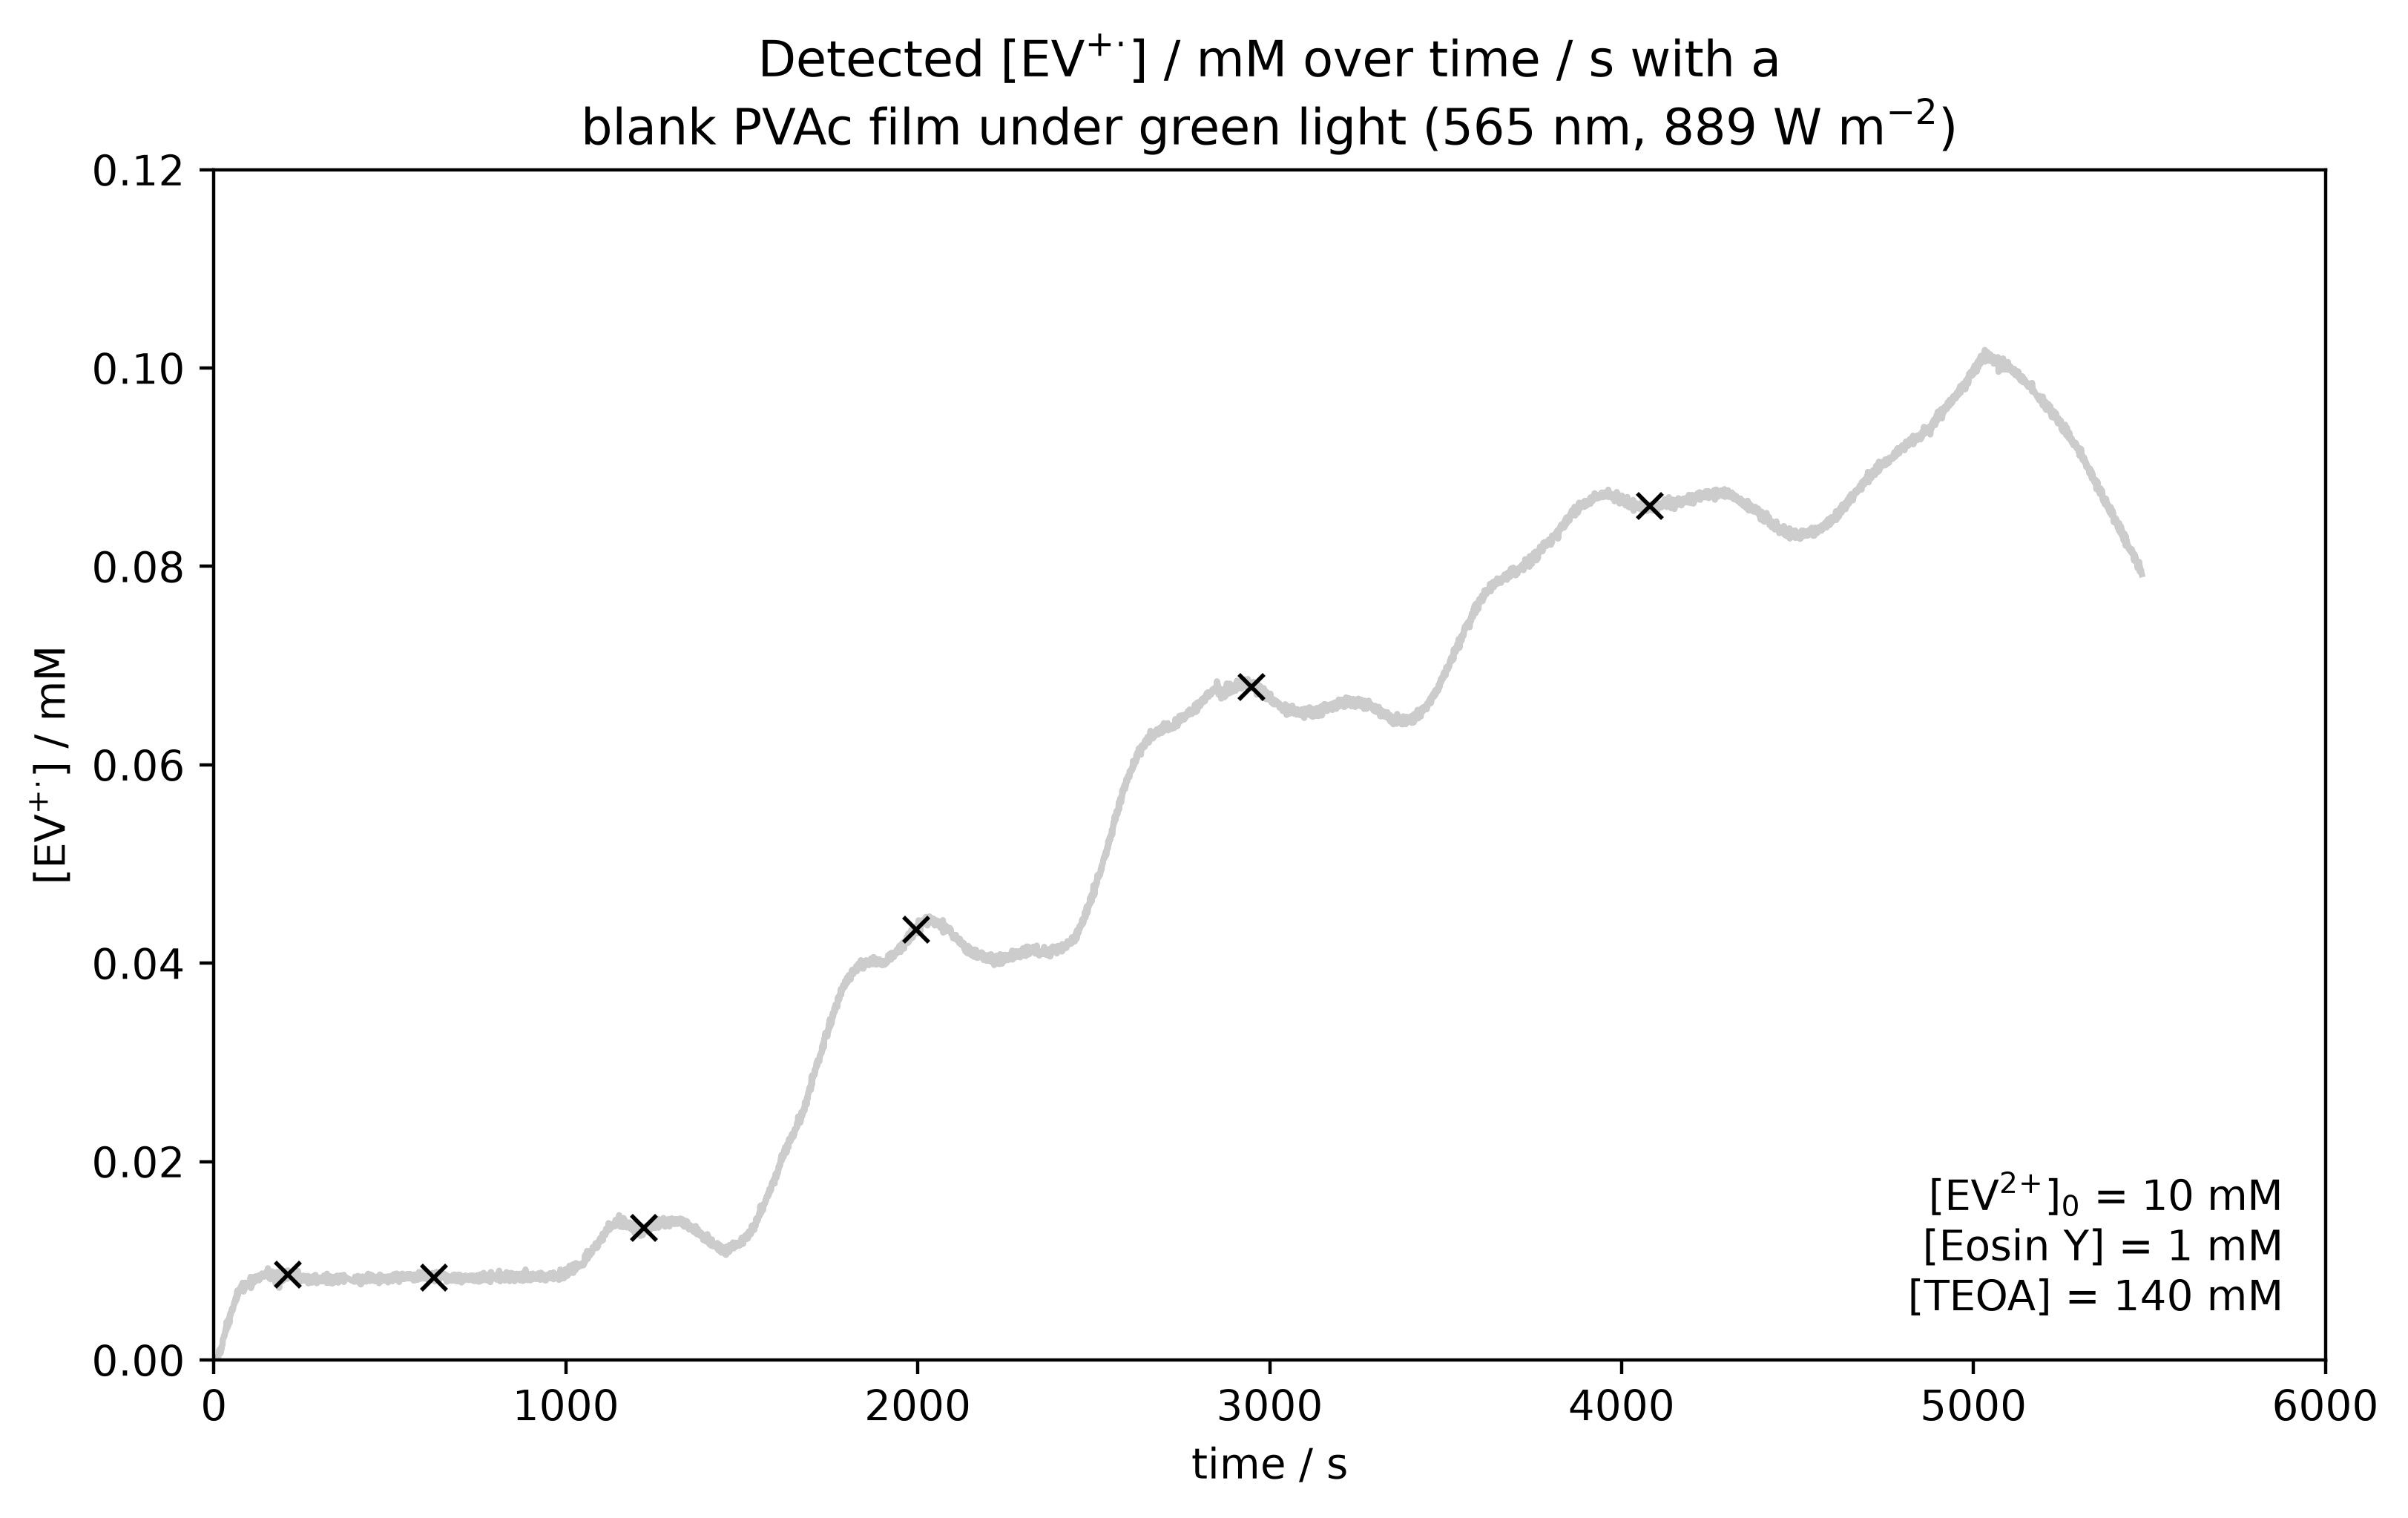

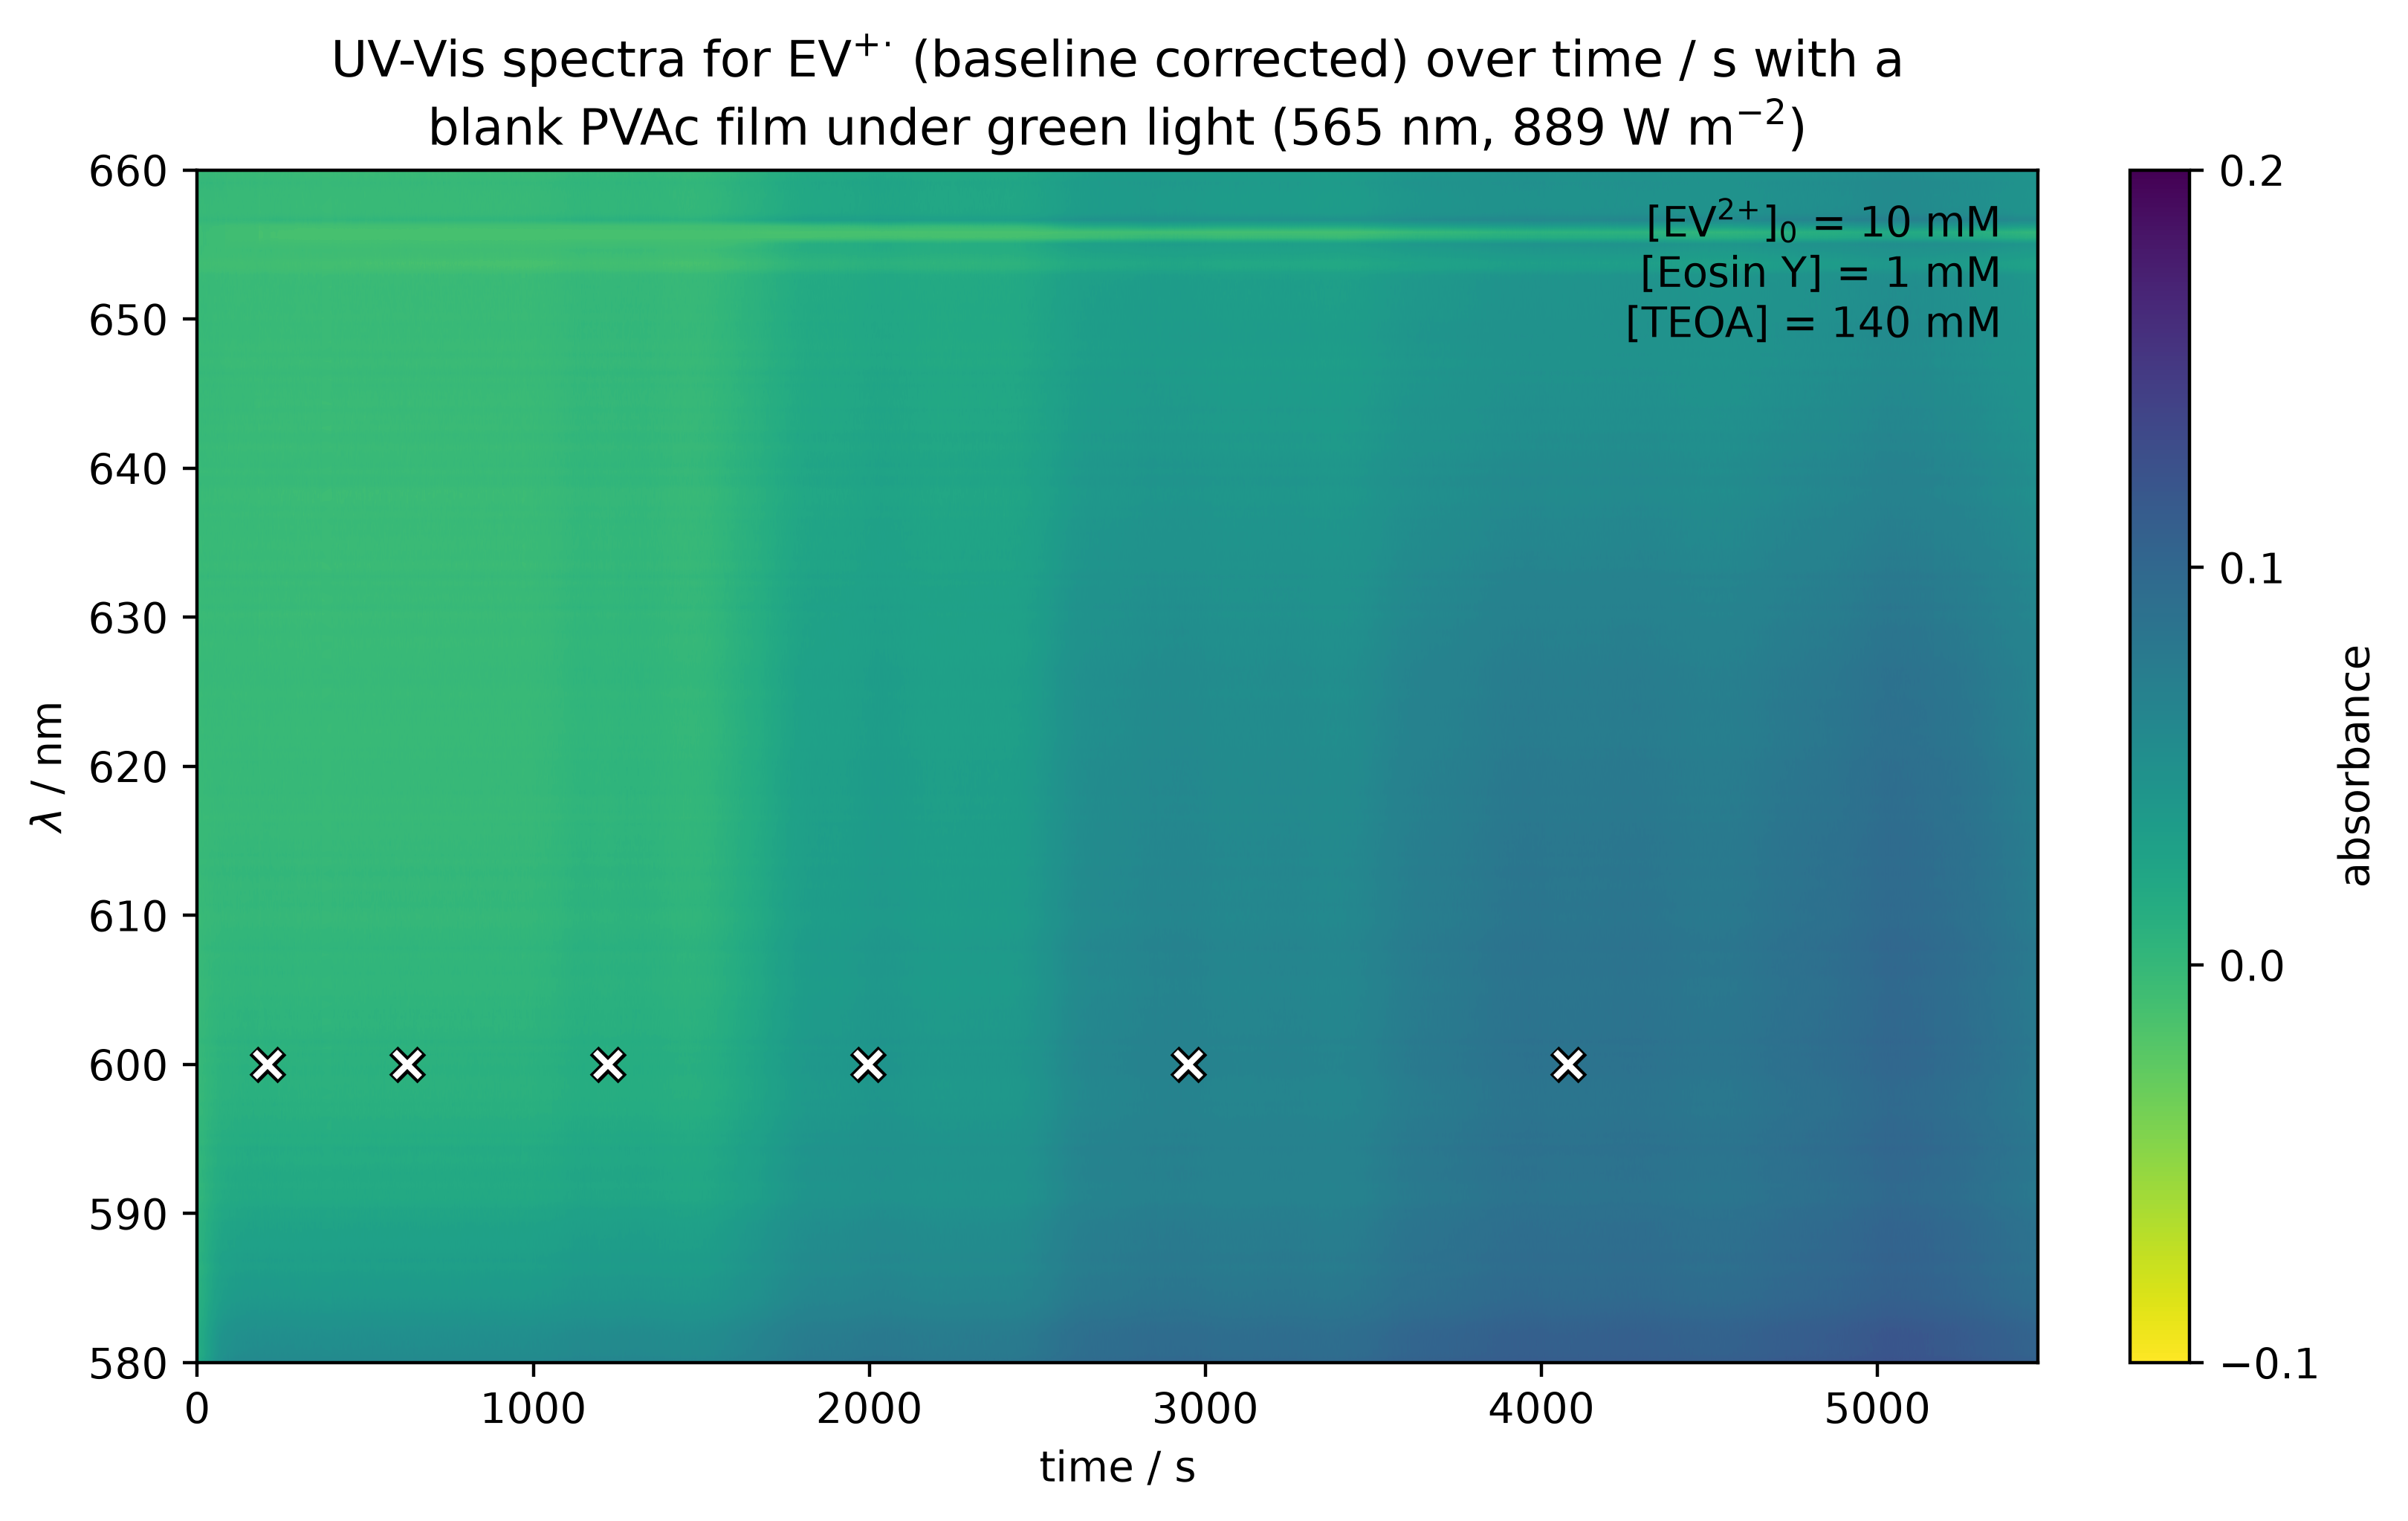

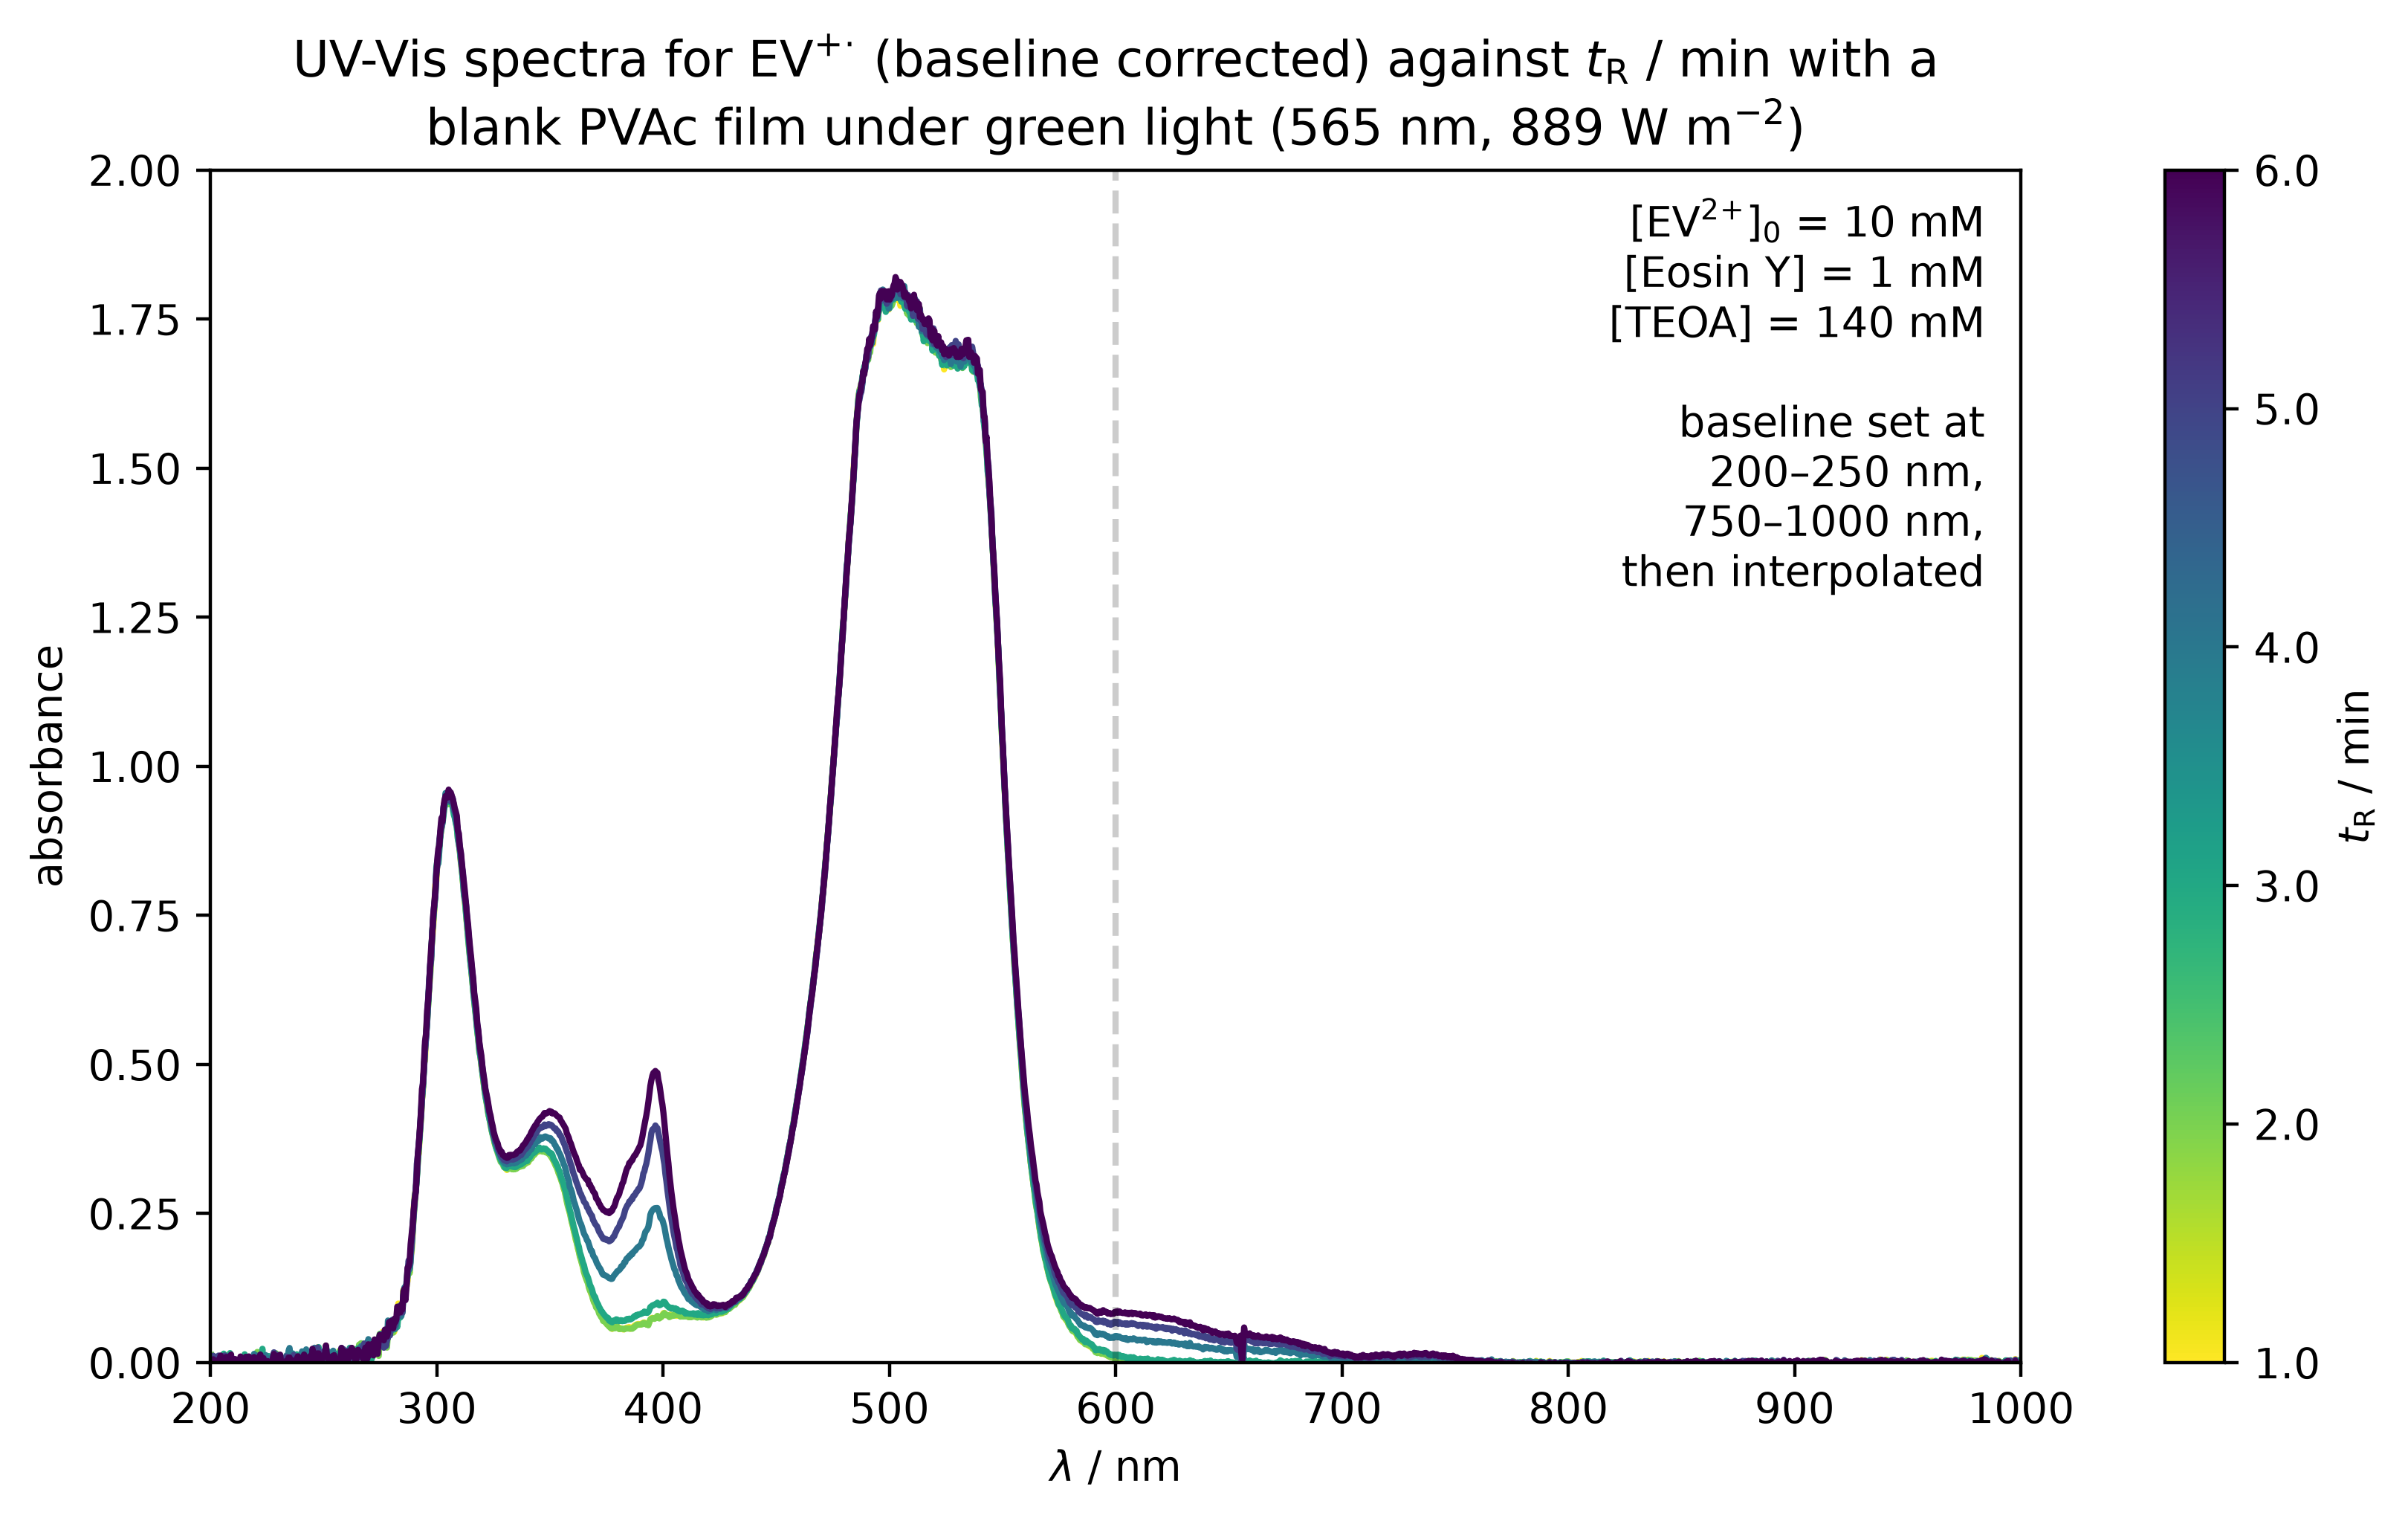

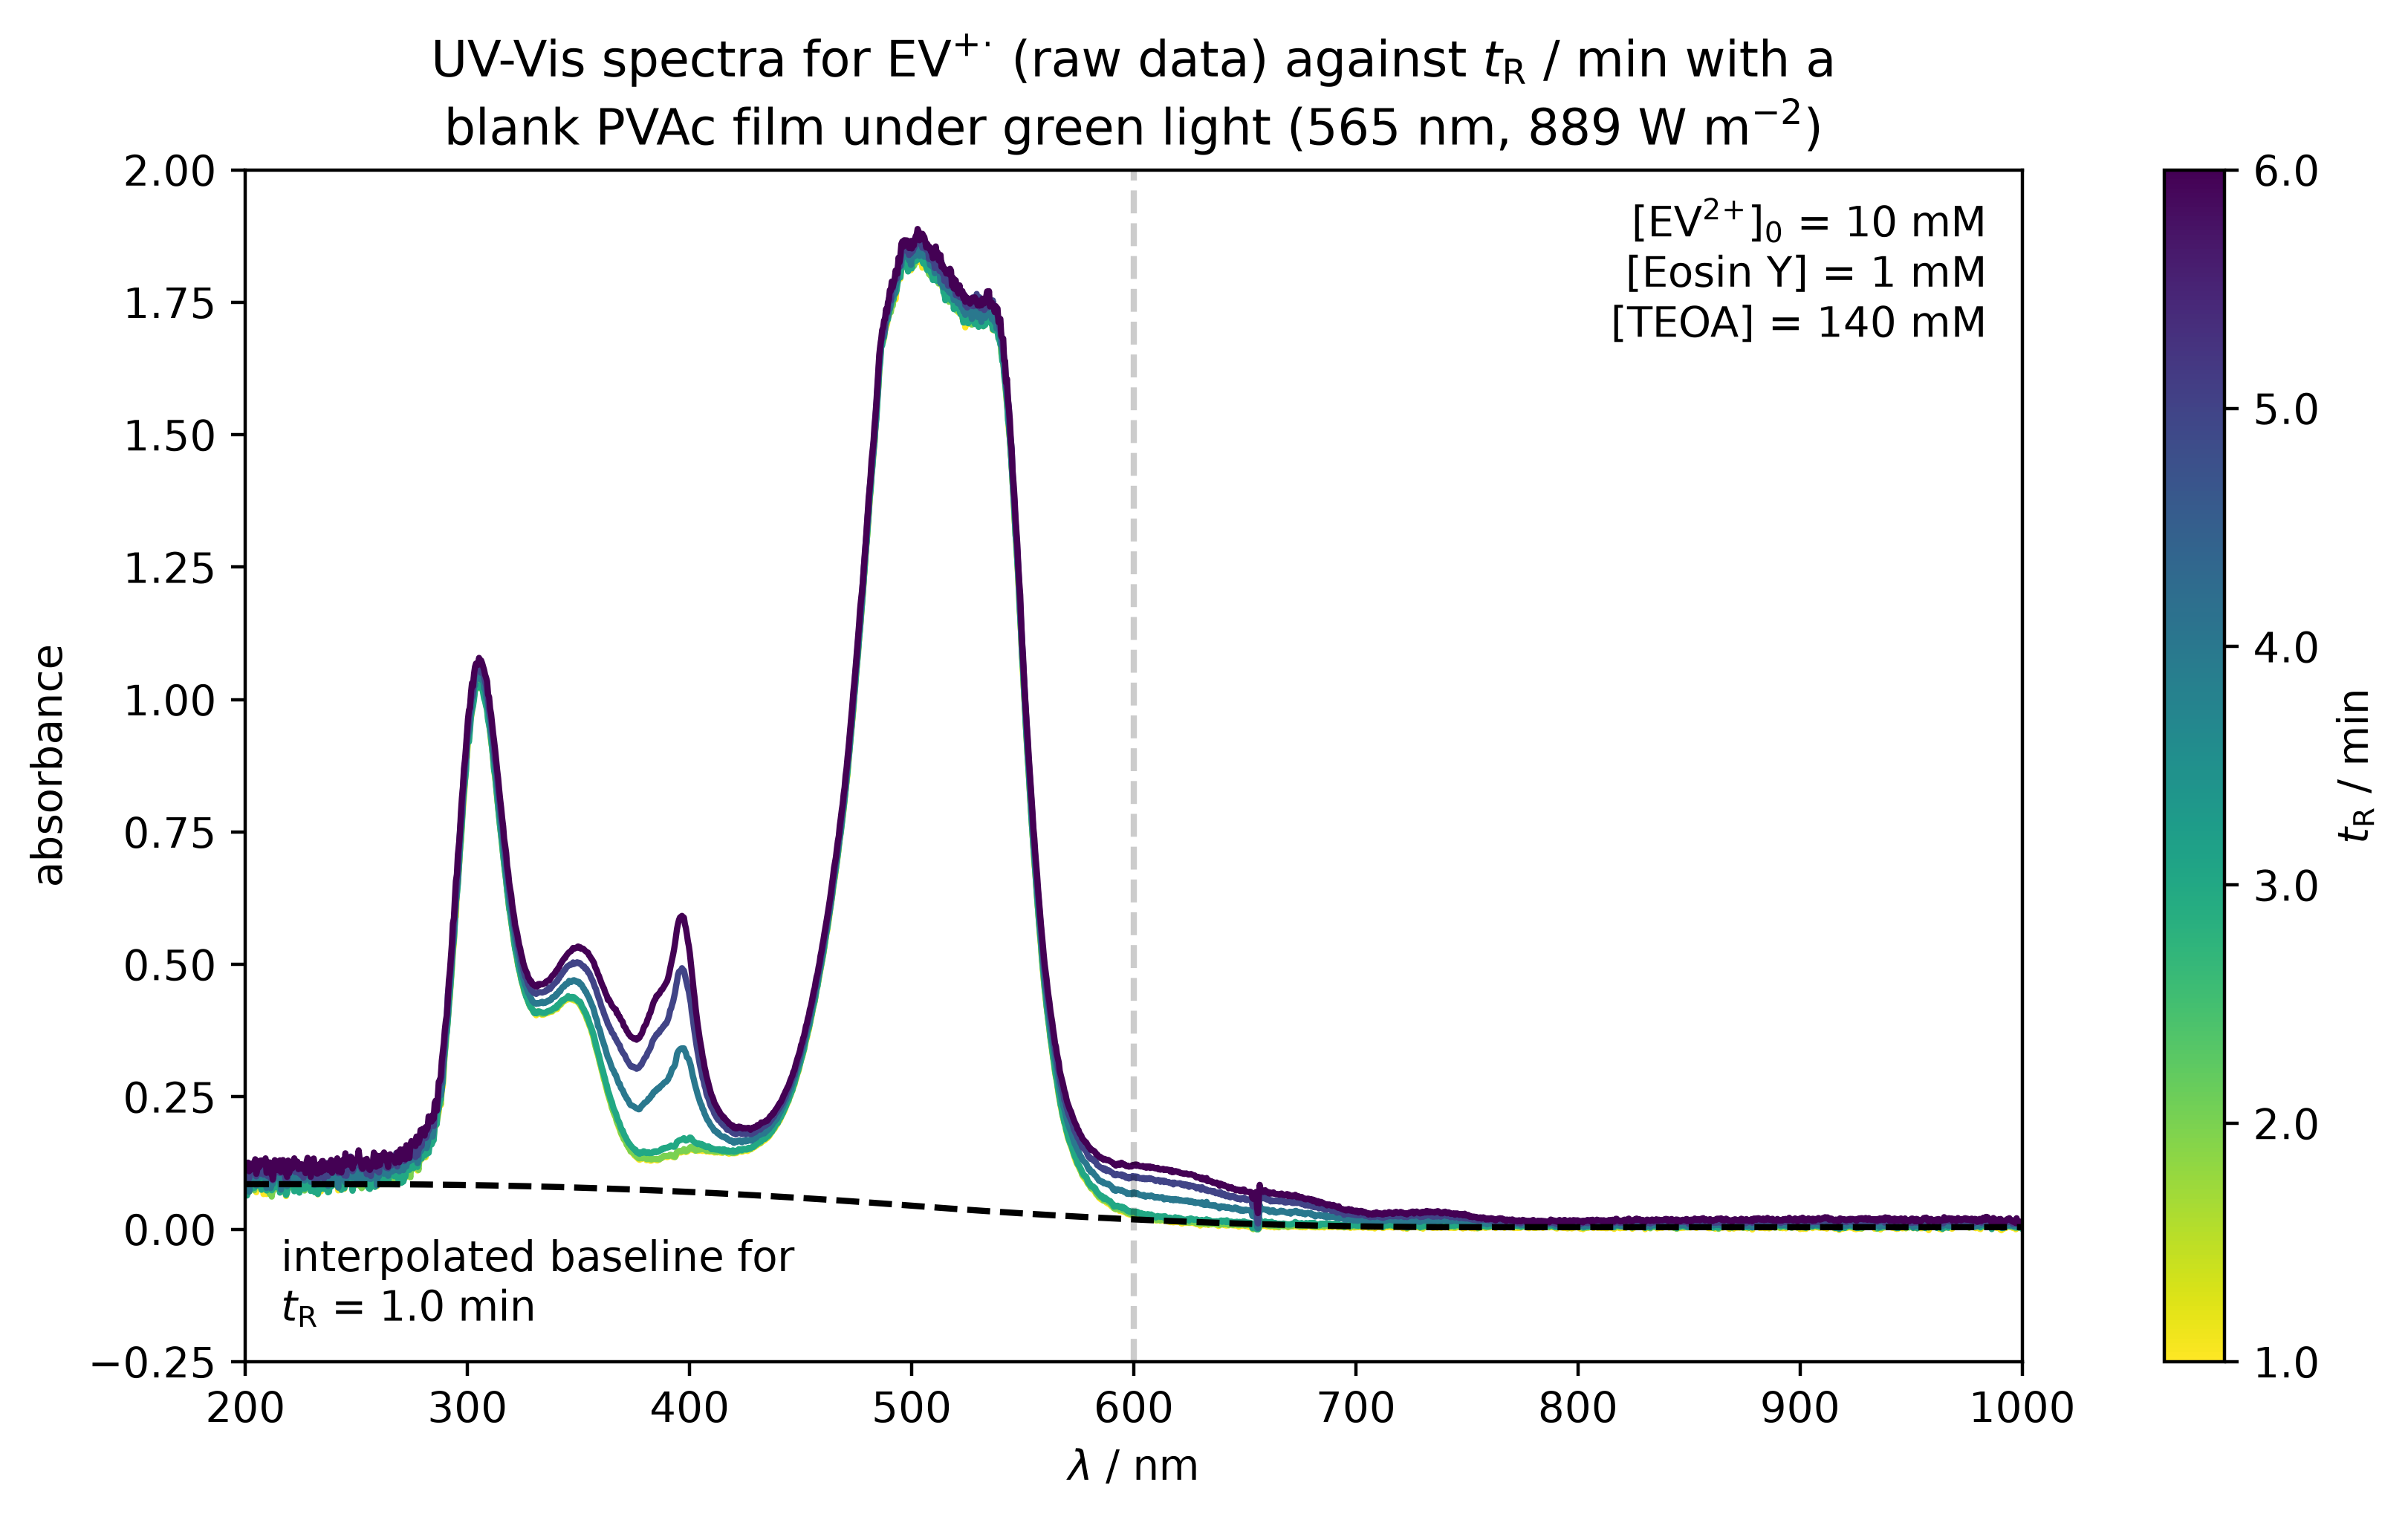

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Green 565 nm irradiation at 63.0 mW.

V(Eosin Y, 5 mM, pH 7 buffer) = 600 ul (1 mM),
V(EV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM),
V(TEOA, 300 mM, pH 7 buffer) = 1400 ul (140 mM).
"""

data = '260811_EosinY_EV_TEOA_Blank_Green_Flow' # data folder name

tRs = np.arange(60, 6*60+1, 60) # residence times/s for 1-6 min in 60 s intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
start = "10-14-00-000" # recorded start time

c0 = 10e-3 # initial EV2+ concentration
details = '[Eosin Y] = 1 mM\n[TEOA] = 140 mM' # concentrations of other reagents

x = 'EVxanthenegreen'
film = 'blank PVAc'
light = 'green'
wavelength = 565e-9 # m
power = 63e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, correction=True)
expt.concvstimeplot(istart=2)
expt.concvstimeplot(ln=True, istart=2)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()